In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries imported.")

Libraries imported.


In [2]:
train_path = "/data/processed/strategy_b/train.csv"

print("Train exists:", os.path.exists(train_path))

train_df = pd.read_csv(train_path)

print("Train shape:", train_df.shape)
print(train_df.columns.tolist())

Train exists: True
Train shape: (11575, 8)
['input_text', 'label', 'Score', 'soru', 'context', 'cevap', 'kaynak', 'veri türü']


In [3]:
def build_input_text_full(row):
    return (
        "Soru: " + str(row["soru"]) + "\n"
        "Bağlam: " + str(row["context"]) + "\n"
        "Cevap: " + str(row["cevap"])
    )

train_df["input_text_before_truncation"] = train_df.apply(build_input_text_full, axis=1)
train_df["length_before_truncation"] = train_df["input_text_before_truncation"].str.len()

print(train_df["length_before_truncation"].describe())

count    11575.000000
mean      5025.156199
std       2171.382069
min        417.000000
25%       3456.000000
50%       4765.000000
75%       6254.500000
max      13449.000000
Name: length_before_truncation, dtype: float64


In [4]:
train_df["length_after_truncation"] = train_df["input_text"].astype(str).str.len()

print(train_df["length_after_truncation"].describe())

count    11575.000000
mean      2846.909460
std        434.644456
min        417.000000
25%       2776.000000
50%       2892.000000
75%       3025.500000
max       7375.000000
Name: length_after_truncation, dtype: float64


In [5]:
figures_dir = "/outputs/figures"
os.makedirs(figures_dir, exist_ok=True)

print("Figures directory:", figures_dir)

Figures directory: /outputs/figures


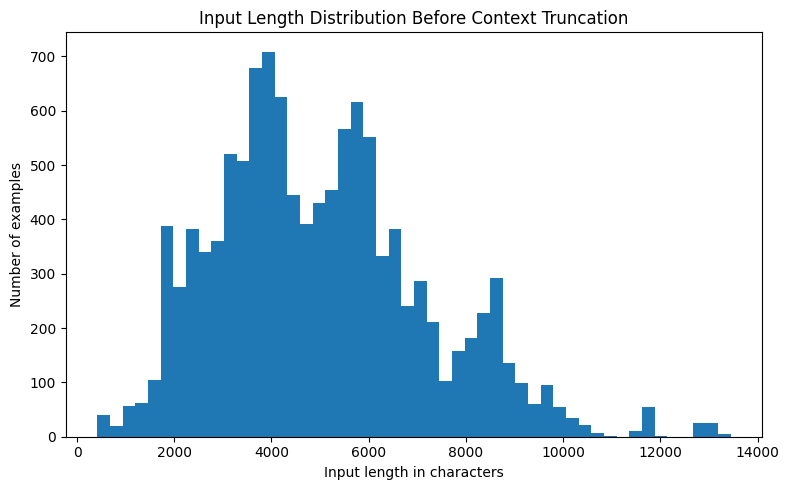

Saved: /outputs/figures/input_length_before_truncation.png


In [6]:
plt.figure(figsize=(8, 5))
plt.hist(train_df["length_before_truncation"], bins=50)
plt.xlabel("Input length in characters")
plt.ylabel("Number of examples")
plt.title("Input Length Distribution Before Context Truncation")
plt.tight_layout()

figure2_path = os.path.join(figures_dir, "input_length_before_truncation.png")
plt.savefig(figure2_path, dpi=300)
plt.show()

print("Saved:", figure2_path)

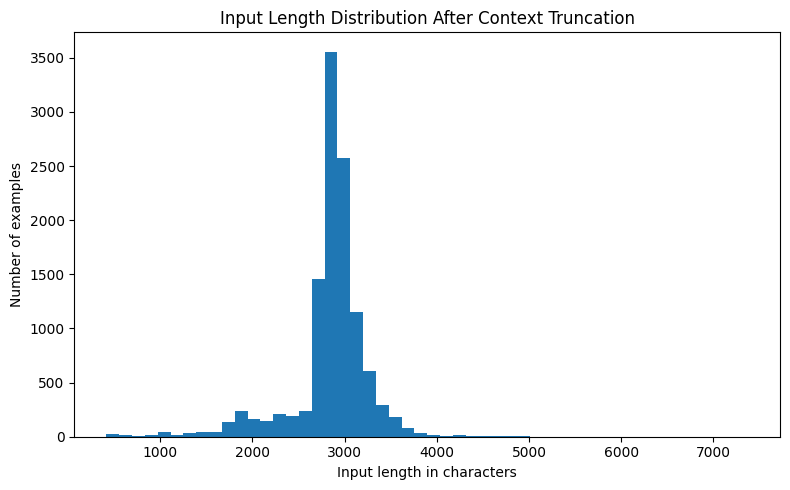

Saved: /outputs/figures/input_length_after_truncation.png


In [7]:
plt.figure(figsize=(8, 5))
plt.hist(train_df["length_after_truncation"], bins=50)
plt.xlabel("Input length in characters")
plt.ylabel("Number of examples")
plt.title("Input Length Distribution After Context Truncation")
plt.tight_layout()

figure3_path = os.path.join(figures_dir, "input_length_after_truncation.png")
plt.savefig(figure3_path, dpi=300)
plt.show()

print("Saved:", figure3_path)

In [8]:
print(os.path.exists(figure2_path))
print(os.path.exists(figure3_path))

True
True


In [9]:
before_95 = train_df["length_before_truncation"].quantile(0.95)
after_95 = train_df["length_after_truncation"].quantile(0.95)

print("Before truncation 95th percentile:", before_95)
print("After truncation 95th percentile:", after_95)

Before truncation 95th percentile: 8820.599999999999
After truncation 95th percentile: 3367.2999999999993
